In [63]:
import os
import zipfile
import requests
import shutil
from pathlib import Path
import kagglehub
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# telechargement du dataset de kaggle
path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images")
path = Path(path)

print("Path to dataset files:", path)



Path to dataset files: /kaggle/input/pcos-detection-using-ultrasound-images


In [64]:
subfolder_path = path / "data" / "train"
categories = ['infected', 'notinfected']
total_train_images = 0
category_counts_train = {category: len(list((subfolder_path / category).glob("*.*"))) for category in categories}

#Calculer le nombre total
total_train_images = sum(category_counts_train.values())
for category, count in category_counts_train.items():
    print(f"{category}: {count} images")

print(f"\nTotal d'images entrainer: {total_train_images}")

infected: 781 images
notinfected: 1143 images

Total d'images entrainer: 1924


In [65]:
#montrer juste le pourcentage
print(f"\nTotal d'images entrainer: {total_train_images}")
for count in category_counts_train.values():
    print(f"{(count / total_train_images) * 100:.2f}%")




Total d'images entrainer: 1924
40.59%
59.41%


In [66]:
subfolder_path = path / "data" / "test"
categories = ['infected', 'notinfected']
total_test_images = 0
category_counts_test = {category: len(list((subfolder_path / category).glob("*.*"))) for category in categories}

#Calculer le nombre total
total_test_images = sum(category_counts_test.values())
for category, count in category_counts_test.items():
    print(f"{category}: {count} images")

print(f"\nTotal d'images a tester: {total_test_images}")


infected: 787 images
notinfected: 1145 images

Total d'images a tester: 1932


In [67]:
#montrer juste le pourcentage
print(f"\nTotal d'images entrainer: {total_test_images}")
for count in category_counts_test.values():
    print(f"{(count / total_train_images) * 100:.2f}%")




Total d'images entrainer: 1932
40.90%
59.51%


In [68]:
#Calculer le total au complet
total_images = total_test_images + total_train_images
print(f"\nTotal images in entire dataset: {total_images}")
for category in categories:
    count = category_counts_test.get(category, 0) + category_counts_train.get(category, 0)
    print(f"{category}: {count} images ({(count / total_images) * 100:.2f}%)")



Total images in entire dataset: 3856
infected: 1568 images (40.66%)
notinfected: 2288 images (59.34%)


In [69]:
print(f"Total Test Images: {total_test_images}")
print(f"Total Train Images: {total_train_images}")


Total Test Images: 1932
Total Train Images: 1924


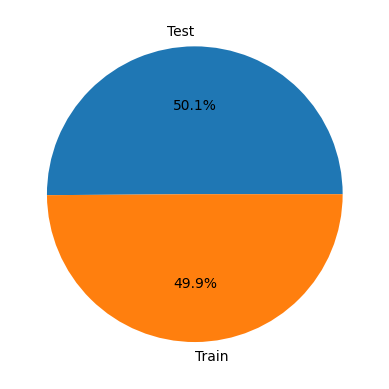

In [84]:
labels = ['Test', 'Train']
sizes = [total_test_images, total_train_images]

plt.pie(sizes,labels=labels, autopct='%1.1f%%')
plt.show()